# Word Embeddings and Recurrent Neural Networks with PyTorch

## Overview

This notebook introduces modern Natural Language Processing (NLP) techniques using PyTorch. It begins by exploring distributed word representations through **Word2Vec** and **GloVe** embeddings, demonstrating how semantic relationships between words can be captured in vector space. It then applies pretrained embeddings to sentiment analysis and concludes by building a recurrent neural network (RNN) for tweet sentiment classification.

The notebook progresses from understanding word representations to developing an end-to-end sequence classification pipeline using recurrent neural networks.



This tutorial is split into three parts. Parts A and B focus on Word2Vec and GloVe word embeddings. Sentiment analysis using GloVe embeddings with a simple ANN classifier is the focus of Part B. Part C introduces recurrent neural networks (RNNs) for sentiment analysis and provides sample code for batching of data.

#Part A: Word2Vec and GloVe Vectors
We saw how autoencoders are used to learn a latent
**embedding space**: an alternative, low-dimensional representation
of a set of data with some appealing properties:
for example, we saw that interpolating in the latent space
is a way of generating new examples. In particular,
interpolation in the latent space generates more compelling
examples than, say, interpolating in the raw pixel space.

The idea of learning an alternative representation/features/*embeddings* of data
is a prevalent one in machine learning. Good representations will
make downstream tasks (like generating new data, clustering, computing distances) perform much better.

With autoencoders, we were able to learn a representation of MNIST digits by using a model that looks like this:

- **Encoder**: data -> embedding
- **Decoder**: embedding -> data

This type of architecture works well for certain types of data (e.g. images)
that are easy to generate, and whose meaning is encoded in the input data
representation (e.g. the pixels).

But what if we want to train an embedding on words? Words are different
from images, in that the meaning of a word is not represented
by the letters that make up the word (the same way that the meaning
of an image is represented by the pixels that make up the pixel). Instead,
the meaning of words comes from how they are used in conjunction with other
words.

## word2vec models

A word2vec model learns embedding of words using the following architecture:

- **Encoder**: word -> embedding
- **Decoder**: embedding -> nearby words (context)

Specific word2vec models differ in the which "nearby words" is predicted
using the decoder: is it the 3 context words that appeared *before*
the input word? Is it the 3 words that appeared *after*? Or is it a combination
of the two words that appeared before and two words that appeared after
the input word?

These models are trained using a large corpus of text: for example the whole
of Wikipedia or a large collection of news articles. We won't train our
own word2vec models in this course, so we won't talk about the many considerations involved in training a word2vec model.

Instead, we will use a set of pre-trained word embeddings. These are embeddings
that someone else took the time and computational power to train.
One of the most commonly-used pre-trained word embeddings are the **GloVe embeddings**.

GloVe is a variation of a word2vec model. Again, the specifics of the algorithm
and its training will be beyond the scope of this course.
You should think of **GloVe embeddings** similarly to pre-trained AlexNet weights in that they "may" provide improvements to the representation of data.

More information about GloVe is available here: https://nlp.stanford.edu/projects/glove/

Unlike AlexNet, there are several variations of GloVe embeddings. They
differ in the corpus used to train the embedding, and the *size* of the embeddings.

## GloVe Embeddings

To load pre-trained GloVe embeddings, we'll use a package called `torchtext`.
The package `torchtext` contains other useful tools for working with text
that we will see later in the course. The documentation for torchtext
GloVe vectors are available at: https://torchtext.readthedocs.io/en/latest/vocab.html#glove

We'll begin by loading a set of GloVe embeddings. The first time you run the code below, Python will download a large file (862MB) containing the pre-trained embeddings.

## Learning Objectives

By completing this notebook, you will learn how to:

- Understand distributed word representations
- Explore Word2Vec and GloVe embeddings
- Measure semantic similarity using cosine similarity
- Solve word analogy tasks with vector arithmetic
- Analyze bias in pretrained word embeddings
- Build sentiment analysis models using pretrained embeddings
- Implement recurrent neural networks (RNNs) in PyTorch
- Process variable-length text sequences
- Train sequence classification models for tweet sentiment analysis

In [52]:
!pip install  torch==2.2.0 torchtext==0.16.2 portalocker>=2.0.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.7.1 which is incompatible.
torchvision 0.26.0+cpu requires torch==2.11.0, but you have torch 2.2.0 which is incompatible.


In [53]:
import torch
import torchtext

# The first time you run this will download a ~823MB file
glove = torchtext.vocab.GloVe(name="6B", # trained on Wikipedia 2014 corpus
                              dim=50)   # embedding size = 50

Let's look at what the embedding of the word "car" looks like:

In [54]:
# Now this will work perfectly!
glove['car']

tensor([ 0.4769, -0.0846,  1.4641,  0.0470,  0.1469,  0.5082, -1.2228, -0.2261,
         0.1931, -0.2976,  0.2060, -0.7128, -1.6288,  0.1710,  0.7480, -0.0619,
        -0.6577,  1.3786, -0.6804, -1.7551,  0.5832,  0.2516, -1.2114,  0.8134,
         0.0948, -1.6819, -0.6450,  0.6322,  1.1211,  0.1611,  2.5379,  0.2485,
        -0.2682,  0.3282,  1.2916,  0.2355,  0.6147, -0.1344, -0.1324,  0.2740,
        -0.1182,  0.1354,  0.0743, -0.6195,  0.4547, -0.3032, -0.2188, -0.5605,
         1.1177, -0.3659])

It is a torch tensor with dimension `(50,)`. It is difficult to determine what each
number in this embedding means, if anything. However, we know that there is structure
in this embedding space. That is, distances in this embedding space is meaningful.

## Measuring Distance

To explore the structure of the embedding space, it is necessary to introduce
a notion of *distance*. You are probably already familiar with the notion
of the **Euclidean distance**. The Euclidean distance of two vectors $x = [x_1, x_2, ... x_n]$ and
$y = [y_1, y_2, ... y_n]$ is just the 2-norm of their difference $x - y$. We can compute
the Euclidean distance between $x$ and $y$:
$\sqrt{\sum_i (x_i - y_i)^2}$

The PyTorch function `torch.norm` computes the 2-norm of a vector for us, so we
can compute the Euclidean distance between two vectors like this:

In [55]:
x = glove['cat']
y = glove['dog']
torch.norm(y - x)

tensor(1.8846)

In [56]:
torch.norm(glove['good'] - glove['bad'])

tensor(3.3189)

In [57]:
torch.norm(glove['good'] - glove['water'])

tensor(5.3390)

In [58]:
torch.norm(glove['good'] - glove['well'])

tensor(2.7703)

In [59]:
torch.norm(glove['good'] - glove['perfect'])

tensor(2.8834)

In [60]:
torch.norm(glove['good'] - glove['bravo'])

tensor(6.2940)

An alternative measure of distance is the **Cosine Similarity**.
The cosine similarity measures the *angle* between two vectors,
and has the property that it only considers the *direction* of the
vectors, not their the magnitudes.

In [61]:
x = torch.tensor([1., 1., 1.]).unsqueeze(0)
y = torch.tensor([2., 2., -2.]).unsqueeze(0)
torch.cosine_similarity(x, y)

tensor([0.3333])

The cosine similarity is a *similarity* measure rather than a *distance* measure:
The larger the similarity,
the "closer" the word embeddings are to each other.

In [62]:
x = glove['cat']
y = glove['dog']
torch.cosine_similarity(x.unsqueeze(0), y.unsqueeze(0))

tensor([0.9218])

In [63]:
torch.cosine_similarity(glove['good'].unsqueeze(0),
                        glove['bad'].unsqueeze(0))

tensor([0.7965])

In [64]:
torch.cosine_similarity(glove['good'].unsqueeze(0),
                        glove['well'].unsqueeze(0))

tensor([0.8511])

In [65]:
torch.cosine_similarity(glove['good'].unsqueeze(0),
                        glove['perfect'].unsqueeze(0))

tensor([0.8376])

In [66]:
torch.cosine_similarity(glove['good'].unsqueeze(0),
                        glove['bravo'].unsqueeze(0))

tensor([0.1991])

## Word Similarity

Now that we have a notion of distance in our embedding space, we can talk
about words that are "close" to each other in the embedding space.
For now, let's use Euclidean distances to look at how close various words
are to the word "cat".

In [67]:
word = 'cat'
other = ['pet', 'dog', 'bike', 'kitten', 'puppy', 'kite', 'computer', 'neuron']
for w in other:
    dist = torch.norm(glove[word] - glove[w]) # euclidean distance
    print(w, float(dist))

pet 3.03967547416687
dog 1.8846030235290527
bike 5.048375129699707
kitten 3.5068607330322266
puppy 3.0644657611846924
kite 4.210376262664795
computer 6.0306525230407715
neuron 6.228668212890625


In fact, we can look through our entire vocabulary for words that are closest
to a point in the embedding space -- for example, we can look for words
that are closest to another word like "cat".

In [68]:
def print_closest_words(vec, n=5):
    # 1. Compute Euclidean distances natively in PyTorch
    # (glove.vectors and vec must be on the same device)
    dists = torch.norm(glove.vectors - vec, dim=1)

    # 2. Use PyTorch's native sort (ascending=True because smaller distance = closer meaning)
    sorted_dists, sorted_indices = torch.sort(dists)

    # 3. Print the top n closest words
    # We skip index 0 because the closest word to "cat" is always "cat" itself (distance 0)
    for i in range(1, n + 1):
        idx = sorted_indices[i].item()      # .item() extracts the raw Python integer
        difference = sorted_dists[i].item() # Extracts the raw distance float
        print(f"{glove.itos[idx]:<15} {difference:.4f}")
print_closest_words(glove["cat"], n=10)

dog             1.8846
rabbit          2.4573
monkey          2.8102
cats            2.8972
rat             2.9455
beast           2.9878
monster         3.0022
pet             3.0397
snake           3.0618
puppy           3.0645


In [69]:
print_closest_words(glove['nurse'])

doctor          3.1275
dentist         3.1307
nurses          3.2687
pediatrician    3.3212
counselor       3.3987


In [70]:
print_closest_words(glove['computer'])

computers       2.4363
software        2.9268
technology      3.1904
electronic      3.5067
computing       3.6000


In [71]:
print_closest_words(glove['elizabeth'])

margaret        2.0075
mary            2.2704
anne            2.3007
catherine       2.6156
katherine       2.7222


In [72]:
print_closest_words(glove['michael'])

peter           2.9221
moore           2.9318
david           2.9446
steven          2.9882
murphy          3.0184


In [73]:
print_closest_words(glove['bravo'])

marlon          3.7966
dwayne          3.8806
coco            3.9080
hooper          3.9350
lara            4.0298


We could also look at which words are closest to the midpoints of two words:

In [74]:
print_closest_words((glove['happy'] + glove['sad']) / 2)

happy           1.9200
feels           2.3605
sorry           2.4985
hardly          2.5259
imagine         2.5653


In [75]:
print_closest_words((glove['lake'] + glove['building']) / 2)

surrounding     3.0698
nearby          3.1112
bridge          3.1586
along           3.1610
shore           3.1619


In [76]:
print_closest_words((glove['bravo'] + glove['michael']) / 2)

farrell         2.8014
anderson        2.8507
jacobs          2.8537
boyle           2.8578
slater          2.8655


In [77]:
print_closest_words((glove['one'] + glove['ten']) / 2)

ten             1.5738
only            1.8805
three           2.0310
five            2.0469
four            2.1126


## Analogies

One surprising aspect of GloVe vectors is that the *directions* in the
embedding space can be meaningful. The structure of the GloVe vectors
certain analogy-like relationship like this tend to hold:

$$ king - man + woman \approx queen $$

In [78]:
print_closest_words(glove['king'] - glove['man'] + glove['woman'])

queen           2.8391
prince          3.6610
elizabeth       3.7153
daughter        3.8318
widow           3.8494


We get reasonable answers like "queen", "throne" and the name of
our current queen.

We can likewise flip the analogy around:

In [79]:
print_closest_words(glove['queen'] - glove['woman'] + glove['man'])

king            2.8391
prince          3.2509
crown           3.4485
knight          3.5587
coronation      3.6199


Or, try a different but related analogies along the gender axis:

In [80]:
print_closest_words(glove['king'] - glove['prince'] + glove['princess'])

queen           3.1846
king            3.9103
bride           4.2857
lady            4.2996
sister          4.4212


In [81]:
print_closest_words(glove['uncle'] - glove['man'] + glove['woman'])

grandmother     2.3234
aunt            2.3528
granddaughter   2.3615
daughter        2.4039
uncle           2.6026


In [82]:
print_closest_words(glove['grandmother'] - glove['mother'] + glove['father'])

uncle           2.0784
father          2.0912
grandson        2.2966
nephew          2.3536
elder           2.4275


In [83]:
print_closest_words(glove['old'] - glove['young'] + glove['father'])

father          4.0327
son             4.4065
grandfather     4.5185
grandson        4.7221
daughter        4.7867


We can move an embedding towards the direction of "goodness" or "badness":

In [84]:
print_closest_words(glove['good'] - glove['bad'] + glove['programmer'])

versatile       4.3816
creative        4.5690
entrepreneur    4.6344
enables         4.7178
intelligent     4.7350


In [85]:
print_closest_words(glove['bad'] - glove['good'] + glove['programmer'])

hacker          3.8384
glitch          4.0039
originator      4.0420
hack            4.0477
serial          4.2251


## Biased in Word Vectors

Machine learning models have an air of "fairness" about them, since models
make decisions without human intervention. However, models can and do learn
whatever bias is present in the training data!

GloVe vectors seems innocuous enough: they are just representations of
words in some embedding space. Even so, we'll show that the structure
of the GloVe vectors encodes the everyday biases present in the texts
that they are trained on.

We'll start with an example analogy:

$$doctor - man + woman \approx ??$$

Let's use GloVe vectors to find the answer to the above analogy:

In [86]:
print_closest_words(glove['doctor'] - glove['man'] + glove['woman'])

nurse           3.1355
pregnant        3.7805
child           3.7835
woman           3.8643
mother          3.9222


The $$doctor - man + woman \approx nurse$$ analogy is very concerning.
Just to verify, the same result does not appear if we flip the gender terms:

In [87]:
print_closest_words(glove['doctor'] - glove['woman'] + glove['man'])

man             3.9336
colleague       3.9755
himself         3.9848
brother         3.9997
another         4.0291


We see similar types of gender bias with other professions.

In [88]:
print_closest_words(glove['programmer'] - glove['man'] + glove['woman'])

prodigy         3.6689
psychotherapist 3.8070
therapist       3.8087
introduces      3.9065
swedish-born    4.1179


Beyond the first result, none of the other words are even related to
programming! In contrast, if we flip the gender terms, we get very
different results:

In [89]:
print_closest_words(glove['programmer'] - glove['woman'] + glove['man'])

setup           4.0022
innovator       4.0662
programmers     4.1730
hacker          4.2257
genius          4.3644


Here are the results for "engineer":

In [90]:
print_closest_words(glove['engineer'] - glove['man'] + glove['woman'])

technician      3.6927
mechanic        3.9213
pioneer         4.1544
pioneering      4.1881
educator        4.2265


In [91]:
print_closest_words(glove['engineer'] - glove['woman'] + glove['man'])

builder         4.3524
mechanic        4.4030
engineers       4.4780
worked          4.5281
replacing       4.6002


In [92]:
print_closest_words(glove['china'] - glove['beijing'] + glove['london'])

britain         3.4587
british         3.5476
uk              3.9198
australia       3.9472
zealand         4.0042


# Part 2 — Sentiment Analysis with GloVe Embeddings

## Sentiment Analysis

Sentiment analysis is a Natural Language Processing (NLP) task that aims to determine the emotional tone or opinion expressed in a piece of text. It has numerous real-world applications, including social media monitoring, product review analysis, customer feedback classification, and opinion mining.

Traditional sentiment analysis methods often rely on manually assigning sentiment scores to individual words and aggregating them to estimate the overall sentiment of a document. While simple, these approaches struggle with complex linguistic phenomena such as negation, sarcasm, and contextual meaning.

In this notebook, sentiment analysis is performed using **pretrained GloVe word embeddings**, which provide dense vector representations that capture semantic relationships between words. These embeddings enable neural networks to learn richer contextual representations than traditional bag-of-words approaches.

The model is trained on the **Sentiment140** dataset, a widely used benchmark containing approximately **1.6 million** Twitter posts labeled as positive or negative based on the emoticons originally included in each tweet. During preprocessing, the emoticons are removed, and the objective becomes predicting the underlying sentiment from the remaining tweet text.

The dataset is loaded directly from a publicly shared Google Drive file, eliminating the need for manual downloads or Google Drive mounting.

**Dataset**

https://drive.google.com/file/d/1sQuD_H1mMfW7tr42DKUuBLFPMJh5NiS8/view?usp=sharing

The following section loads the dataset and explores its structure before constructing the sentiment classification pipeline.

In [93]:
!pip install -q gdown


In [94]:
import csv
import gdown
import torch
import torchtext
import numpy as np
import matplotlib.pyplot as plt

# Shared Google Drive link
url = "https://drive.google.com/uc?id=1sQuD_H1mMfW7tr42DKUuBLFPMJh5NiS8"

# Download only if needed
gdown.download(
    url,
    "training.1600000.processed.noemoticon.csv",
    quiet=False
)

def get_data():
    return csv.reader(
        open(
            "training.1600000.processed.noemoticon.csv",
            "rt",
            encoding="latin-1"
        )
    )

def split_tweet(tweet):
    tweet = (
        tweet.replace(".", " . ")
             .replace(",", " , ")
             .replace(";", " ; ")
             .replace("?", " ? ")
    )
    return tweet.lower().split()

glove = torchtext.vocab.GloVe(
    name="6B",
    dim=50,
    max_vectors=10000
)

Downloading...
From (original): https://drive.google.com/uc?id=1sQuD_H1mMfW7tr42DKUuBLFPMJh5NiS8
From (redirected): https://drive.google.com/uc?id=1sQuD_H1mMfW7tr42DKUuBLFPMJh5NiS8&confirm=t&uuid=850ece14-44f5-4d04-a3c5-83c594e7d04a
To: /content/training.1600000.processed.noemoticon.csv
100%|██████████| 239M/239M [00:03<00:00, 73.8MB/s]


In [95]:
# print only the first tweet
for i, line in enumerate(get_data()):
    if line[0] != '0':
        print(line[0], line[-1])
        break

4 I LOVE @Health4UandPets u guys r the best!! 


The columns we care about is the first one and the last one. The first column is the
label (the label `0` means "sad" tweet, `4` means "happy" tweet), and the last column
contains the tweet. Our task is to predict the sentiment of the tweet given the text.

The approach today is as follows, for each tweet:

1. We will split the text into words. We will do so by splitting at all whitespace
   characters. There are better ways to perform the split, but let's keep our
   dependencies light.
2. We will look up the GloVe embedding of each word.
   Words that do not have a GloVe vector will be ignored.
3. We will sum up all the embeddings, to get an embedding for an entire tweet.
4. Finally, we will use a fully-connected neural network
   to predict whether the tweet has positive or negative sentiment.

First, let's sanity check that there are enough words for us to work with.

In [96]:
import torchtext
glove = torchtext.vocab.GloVe(name="6B", dim=50)

def split_tweet(tweet):
    # separate punctuations
    tweet = tweet.replace(".", " . ") \
                 .replace(",", " , ") \
                 .replace(";", " ; ") \
                 .replace("?", " ? ")
    return tweet.lower().split()

split_tweet("hello; don't you know?")

['hello', ';', "don't", 'you', 'know', '?']

In [97]:

# verify that each tweet has a reasonable number of words
# that have GloVe embeddings
for i, line in enumerate(get_data()):
    if i > 30:
        break
    print(sum(int(w in glove.stoi) for w in split_tweet(line[-1])))

21
23
17
10
22
4
3
21
4
3
9
4
19
15
19
18
18
4
9
13
11
23
8
9
4
11
13
6
23
20
13


Looks like each tweet has at least one word that has an embedding.

Now, steps 1-3 from above can be done ahead of time, just like the transfer learning
portion of Lab 2. So, we will write a function that will take the tweets data
file, computes the tweet embeddings, and splits the data into train/validation/test.

We will only use $\frac{1}{59}$ of the data in the file, so that this demo runs
relatively quickly.

In [98]:
import torch
import torch.nn as nn

def get_tweet_vectors(glove_vector):
    train, valid, test = [], [], []
    for i, line in enumerate(get_data()):
        tweet = line[-1]
        if i % 59 == 0:
            # obtain an embedding for the entire tweet
            tweet_emb = sum(glove_vector[w] for w in split_tweet(tweet))
            # generate a label: 1 = happy, 0 = sad
            label = torch.tensor(int(line[0] == "4")).long()
            # place the data set in either the training, validation, or test set
            if i % 5 < 3:
                train.append((tweet_emb, label)) # 60% training
            elif i % 5 == 4:
                valid.append((tweet_emb, label)) # 20% validation
            else:
                test.append((tweet_emb, label)) # 20% test
    return train, valid, test

I'm making the `glove_vector` a parameter so that we can test the effect
of using a higher dimensional GloVe
embedding later. Now, let's get our training, validation, and test set.
The format is what `torch.utils.data.DataLoader` expects.

In [99]:
import torchtext

glove = torchtext.vocab.GloVe(name="6B", dim=50)

train, valid, test = get_tweet_vectors(glove)

train_loader = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=128, shuffle=True)

Now, our actual training script! Note that will we use `CrossEntropyLoss`,
have two neurons in the final layer of our output layer, and use softmax instead of
a sigmoid activation. This is different from our choice in the earlier weeks!
Typically, machine learning practitioners will choose to use two output
neurons instead of one, even in a binary classification task. The reason is that
an extra neuron adds some more parameters to the network, and makes the network
a little easier to train (performs better).

In [101]:
import matplotlib.pyplot as plt

def train_network(model, train_loader, valid_loader, num_epochs=5, learning_rate=1e-5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses, train_acc, valid_acc = [], [], []
    epochs = []
    for epoch in range(num_epochs):
        for tweets, labels in train_loader:
            optimizer.zero_grad()
            pred = model(tweets)
            loss = criterion(pred, labels)
            loss.backward()
            optimizer.step()

        losses.append(float(loss))
        if epoch % 5 == 4:
            epochs.append(epoch)
            train_acc.append(get_accuracy(model, train_loader))
            valid_acc.append(get_accuracy(model, valid_loader))
            print("Epoch %d; Loss %f; Train Acc %f; Val Acc %f" % (
                epoch+1, loss, train_acc[-1], valid_acc[-1]))

    # plotting
    plt.title("Training Curve")
    plt.plot(losses, label="Train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_acc, label="Train")
    plt.plot(epochs, valid_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

def get_accuracy(model, data_loader):
    correct, total = 0, 0
    for tweets, labels in data_loader:
        output = model(tweets)
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += labels.shape[0]
    return correct / total

As for the actual mode, we will start with a 3-layer neural network.
We won't create our own class since this is a fairly straightforward neural
network, so an `nn.Sequential` object will do.
Let's build and train our network.

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.0
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Epoch 5; Loss 0.770548; Train Acc 0.649130; Val Acc 0.649336
Epoch 10; Loss 0.633475; Train Acc 0.669473; Val Acc 0.665192
Epoch 15; Loss 0.748040; Train Acc 0.672608; Val Acc 0.668879
Epoch 20; Loss 0.594097; Train Acc 0.675804; Val Acc 0.674410
Epoch 25; Loss 0.611346; Train Acc 0.680843; Val Acc 0.672382
Epoch 30; Loss 0.774636; Train Acc 0.681765; Val Acc 0.673304
Epoch 35; Loss 0.580994; Train Acc 0.682072; Val Acc 0.673119
Epoch 40; Loss 0.485009; Train Acc 0.683609; Val Acc 0.673857
Epoch 45; Loss 0.512621; Train Acc 0.683793; Val Acc 0.680494
Epoch 50; Loss 0.449127; Train Acc 0.685084; Val Acc 0.682706
Epoch 55; Loss 0.342161; Train Acc 0.686805; Val Acc 0.676991
Epoch 60; Loss 0.658834; Train Acc 0.688464; Val Acc 0.686763
Epoch 65; Loss 0.922049; Train Acc 0.691045; Val Acc 0.681416
Epoch 70; Loss 0.678164; Train Acc 0.691906; Val Acc 0.684919
Epoch 75; Loss 0.610236; Train Acc 0.692213; Val Acc 0.684181
Epoch 80; Loss 0.474813; Train Acc 0.696454; Val Acc 0.683628
Epoch 85;

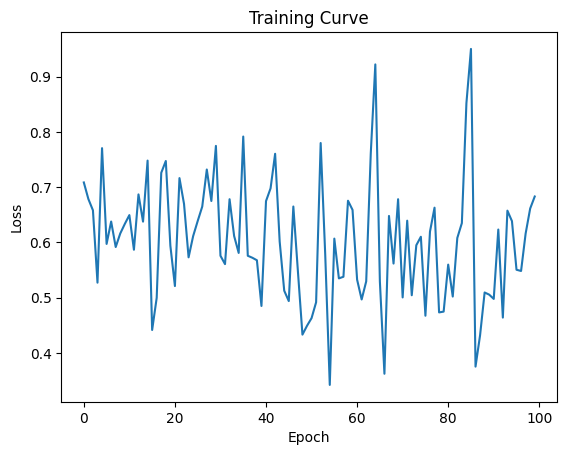

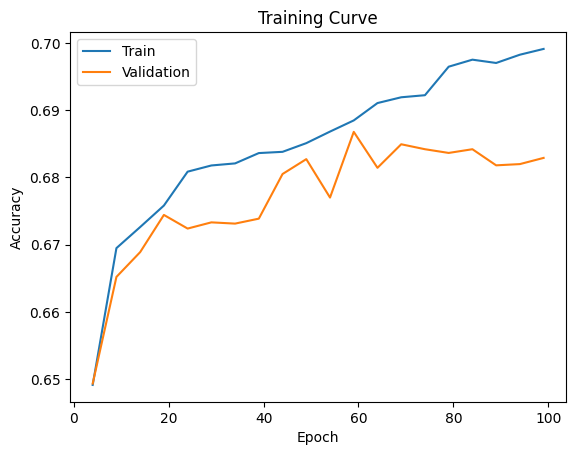

Final test accuracy: 0.6882374631268436


In [102]:
mymodel = nn.Sequential(nn.Linear(50, 30),
                        nn.ReLU(),
                        nn.Linear(30, 10),
                        nn.ReLU(),
                        nn.Linear(10, 2))
train_network(mymodel, train_loader, valid_loader, num_epochs=100, learning_rate=1e-4)
print("Final test accuracy:", get_accuracy(mymodel, test_loader))

In [103]:
def test_model(model, glove_vector, tweet):
    emb = sum(glove_vector[w] for w in split_tweet(tweet))
    out = mymodel(emb.unsqueeze(0))
    pred = out.max(1, keepdim=True)[1]
    return pred

test_model(mymodel, glove, "very happy")

tensor([[1]])

In [104]:
test_model(mymodel, glove, "This is a terrible tragedy")

tensor([[0]])

In [105]:
test_model(mymodel, glove, "okay")

tensor([[0]])

Note that the model does not perform very well, but it does get it right from time to time. There are a number of things we could try to improve the performance, for example changing the number of hidden units, number of layers, or change the dimension of the Glove embeddings.

Another option is to use a more powerful architecture.

#Part C: Recurrent Neural Networks

One of the drawbacks of the previous approach is that the order of
words is lost. The tweets "the cat likes the dog" and "the dog likes the cat"
would have the exact same embedding, even though the sentences have different
meanings.

For this part we will use a **recurrent neural network**. We will treat each tweet
as a **sequence** of words. Like before, we will use GloVe embeddings as inputs
to the recurrent network. (As a sidenote, not all recurrent neural networks use
word embeddings as input. If we had a small enough vocabulary, we could have used
a one-hot embedding of the words.)

In [106]:

import csv
import gdown
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchtext
import numpy as np
import matplotlib.pyplot as plt

# Download the Sentiment140 dataset from a shared Google Drive link
url = "https://drive.google.com/uc?id=1sQuD_H1mMfW7tr42DKUuBLFPMJh5NiS8"
output = "training.1600000.processed.noemoticon.csv"

gdown.download(url, output, quiet=False)

def get_data():
    """Load the Sentiment140 dataset."""
    return csv.reader(open(output, "rt", encoding="latin-1"))

def split_tweet(tweet):
    """Tokenize a tweet by separating punctuation and converting to lowercase."""
    tweet = (
        tweet.replace(".", " . ")
             .replace(",", " , ")
             .replace(";", " ; ")
             .replace("?", " ? ")
    )
    return tweet.lower().split()

# Load the 10,000 most common pretrained GloVe word vectors
glove = torchtext.vocab.GloVe(
    name="6B",
    dim=50,
    max_vectors=10000
)

Downloading...
From (original): https://drive.google.com/uc?id=1sQuD_H1mMfW7tr42DKUuBLFPMJh5NiS8
From (redirected): https://drive.google.com/uc?id=1sQuD_H1mMfW7tr42DKUuBLFPMJh5NiS8&confirm=t&uuid=61e23109-4b77-4e9d-af23-49019f4d2f5c
To: /content/training.1600000.processed.noemoticon.csv
100%|██████████| 239M/239M [00:05<00:00, 45.2MB/s]


Since we are going to store the individual words in a tweet,
we will defer looking up the word embeddings.
Instead, we will store the **index** of each word in a PyTorch tensor.
Our choice is the most memory-efficient, since it takes fewer bits to
store an integer index than a 50-dimensional vector or a word.

In [107]:
def get_tweet_words(glove_vector):
    train, valid, test = [], [], []
    for i, line in enumerate(get_data()):
        if i % 29 == 0:
            tweet = line[-1]
            idxs = [glove_vector.stoi[w]        # lookup the index of word
                    for w in split_tweet(tweet)
                    if w in glove_vector.stoi] # keep words that has an embedding
            if not idxs: # ignore tweets without any word with an embedding
                continue
            idxs = torch.tensor(idxs) # convert list to pytorch tensor
            label = torch.tensor(int(line[0] == "4")).long()
            if i % 5 < 3:
                train.append((idxs, label))
            elif i % 5 == 4:
                valid.append((idxs, label))
            else:
                test.append((idxs, label))
    return train, valid, test

train, valid, test = get_tweet_words(glove)

Here's what an element of the training set looks like:

In [108]:
tweet, label = train[0]
print(tweet)
print(label)

tensor([   2,   11,    1,    7,    2,   81,  405,  684, 9912,    3,  245,  122,
           4,   88,   20,    2,   89, 1968])
tensor(0)


Unlike in the past, each element of the training set will have a
different shape. The difference will present some difficulties when
we discuss batching later on.

In [109]:
for i in range(10):
    tweet, label = train[i]
    print(tweet.shape)

torch.Size([18])
torch.Size([23])
torch.Size([8])
torch.Size([20])
torch.Size([6])
torch.Size([5])
torch.Size([10])
torch.Size([8])
torch.Size([7])
torch.Size([31])


## Embedding

We are also going to use an `nn.Embedding` layer, instead of using the variable
`glove` directly. The reason is that the `nn.Embedding` layer allows us look up
the embeddings of multiple words simultaneously.

In [110]:
glove_emb = nn.Embedding.from_pretrained(glove.vectors)

# Example: we use the forward function of glove_emb to lookup the
# embedding of each word in `tweet`
tweet_emb = glove_emb(tweet)
tweet_emb.shape

torch.Size([31, 50])

## Recurrent Neural Network Module

PyTorch has variations of recurrent neural network modules.
These modules computes the following:

$$hidden = updatefn(hidden, input)$$
$$output = outputfn(hidden)$$

These modules are more complex and less intuitive than the usual
neural network layers, so let's take a look:

In [111]:
rnn_layer = nn.RNN(input_size=50,    # dimension of the input repr
                   hidden_size=50,   # dimension of the hidden units
                   batch_first=True) # input format is [batch_size, seq_len, repr_dim]

Now, let's try and run this untrained `rnn_layer` on `tweet_emb`.
We will need to add an extra dimension to `tweet_emb` to account for
batching. We will also need to initialize a set of hidden units of size
`[batch_size, 1, repr_dim]`, to be used for the *first* set of computations.

![](imgs/rnn.png)

In [112]:
tweet_input = tweet_emb.unsqueeze(0) # add the batch_size dimension
h0 = torch.zeros(1, 1, 50)           # initial hidden state
out, last_hidden = rnn_layer(tweet_input, h0)

We don't technically have to explictly provide the initial hidden state,
if we want to use an initial state of zeros. Just for today, we will be
explicit about the hidden states that we provide.

In [113]:
out2, last_hidden2 = rnn_layer(tweet_input)

Now, let's look at the output and hidden dimensions that we have:

In [114]:
print(out.shape)
print(last_hidden.shape)

torch.Size([1, 31, 50])
torch.Size([1, 1, 50])


The shape of the hidden units is the same as our initial `h0`.
The variable `out`, though, has the same shape as our `input`.
The variable contains the concatenation of all of the output units
for each word (i.e. at each time point).

Normally, we only care about the output at the **final** time point,
which we can extract like this.

In [115]:
out[:,-1,:]

tensor([[ 2.0872e-01,  4.3674e-01,  7.0743e-02,  3.5077e-02, -3.9048e-01,
         -5.4027e-01, -4.0016e-01, -5.5820e-01,  1.2192e-01,  1.6424e-01,
         -3.7390e-01, -7.3714e-02, -1.0101e-01, -6.2146e-01, -2.9965e-01,
          7.4348e-01,  4.9379e-01, -1.5262e-01, -3.1690e-01,  3.6463e-01,
         -4.2430e-01,  2.9010e-01,  3.3228e-01,  5.6834e-01,  3.5026e-01,
          5.1538e-02, -1.2181e-01, -7.7659e-01,  7.0469e-01, -2.9625e-01,
          3.8805e-01, -6.6341e-02,  2.3724e-01, -1.1576e-01, -4.0121e-01,
          4.6960e-01,  4.9886e-01, -5.3793e-01,  2.6820e-01, -5.4583e-02,
         -3.9746e-01, -6.5813e-01,  4.8243e-01, -4.0443e-01, -1.1514e-01,
         -1.6999e-01, -6.7826e-01, -4.7456e-01,  2.4725e-04, -8.0385e-02]],
       grad_fn=<SliceBackward0>)

This tensor summarizes the entire tweet, and can be used as an input
to a classifier.

## Building a Model

Let's put both the embedding layer, the RNN and the classifier into one model:

In [116]:
class TweetRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(TweetRNN, self).__init__()
        self.emb = nn.Embedding.from_pretrained(glove.vectors)
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Look up the embedding
        x = self.emb(x)
        # Set an initial hidden state
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        # Forward propagate the RNN
        out, _ = self.rnn(x, h0)
        # Pass the output of the last time step to the classifier
        out = self.fc(out[:, -1, :])
        return out

model = TweetRNN(50, 50, 2)

We should be able to train this model similar to any other model that we have trained before. However, there is one caveat that we have been avoiding this entire time, **batching**.

## Batching

Unfortunately, we will not be able to use `DataLoader` with a
`batch_size` of greater than one. This is because each tweet has
a different shaped tensor.

In [117]:
for i in range(10):
    tweet, label = train[i]
    print(tweet.shape)

torch.Size([18])
torch.Size([23])
torch.Size([8])
torch.Size([20])
torch.Size([6])
torch.Size([5])
torch.Size([10])
torch.Size([8])
torch.Size([7])
torch.Size([31])


PyTorch implementation of `DataLoader` class expects all data samples
to have the same shape. So, if we create a DataLoader like below,
it will throw an error when we try to iterate over its elements.

In [118]:
#will_fail = torch.utils.data.DataLoader(train, batch_size=128)

So, we will need a different way of batching.

One strategy is to **pad shorter sequences with zero inputs**, so that
every sequence is the same length. The following PyTorch utilities
are helpful.

- `torch.nn.utils.rnn.pad_sequence`
- `torch.nn.utils.rnn.pad_packed_sequence`
- `torch.nn.utils.rnn.pack_sequence`
- `torch.nn.utils.rnn.pack_padded_sequence`

(Actually, there are more powerful helpers in the `torchtext` module
that we will use in Lab 4. We'll stick to these in this demo, so that
you can see what's actually going on under the hood.)

In [119]:
from torch.nn.utils.rnn import pad_sequence

tweet_padded = pad_sequence([tweet for tweet, label in train[:10]],
                            batch_first=True)
print(tweet_padded.shape)
print(tweet_padded[0:2])

torch.Size([10, 31])
tensor([[   2,   11,    1,    7,    2,   81,  405,  684, 9912,    3,  245,  122,
            4,   88,   20,    2,   89, 1968,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0],
        [ 192,    2,   41, 4284,   83,    0,   31, 1096,    4,   88,   17,   20,
          188,   83,  100,    1,  500,    1,   41,  169,   20,    1,  837,    0,
            0,    0,    0,    0,    0,    0,    0]])


Now, we can pass multiple tweets in a batch through the RNN at once!

In [120]:
out = model(tweet_padded)
print(out.shape)

torch.Size([10, 2])


One issue we overlooked was that in our `TweetRNN` model, we always
take the **last output unit** as input to the final classifier. Now
that we are padding the input sequences, we should really be using
the output at a previous time step. Recurrent neural networks therefore
require much more record keeping than ANNs or even CNNs.

There is yet another problem:
the longest tweet has many, many more words than the shortest.
Padding tweets so that every tweet has the same length as the longest
tweet is impractical. Padding tweets in a mini-batch, however, is much
more reasonable.

In practice, practitioners will batch together tweets with the same
length. For simplicity, we will do the same. We will implement a (more or less)
straightforward way to batch tweets.

In [121]:
import random

class TweetBatcher:
    def __init__(self, tweets, batch_size=32, drop_last=False):
        # store tweets by length
        self.tweets_by_length = {}
        for words, label in tweets:
            # compute the length of the tweet
            wlen = words.shape[0]
            # put the tweet in the correct key inside self.tweet_by_length
            if wlen not in self.tweets_by_length:
                self.tweets_by_length[wlen] = []
            self.tweets_by_length[wlen].append((words, label),)

        #  create a DataLoader for each set of tweets of the same length
        self.loaders = {wlen : torch.utils.data.DataLoader(
                                    tweets,
                                    batch_size=batch_size,
                                    shuffle=True,
                                    drop_last=drop_last) # omit last batch if smaller than batch_size
            for wlen, tweets in self.tweets_by_length.items()}

    def __iter__(self): # called by Python to create an iterator
        # make an iterator for every tweet length
        iters = [iter(loader) for loader in self.loaders.values()]
        while iters:
            # pick an iterator (a length)
            im = random.choice(iters)
            try:
                yield next(im)
            except StopIteration:
                # no more elements in the iterator, remove it
                iters.remove(im)

Let's take a look at our batcher in action. We will set `drop_last` to be true for training,
so that all of our batches have exactly the same size.

In [122]:
for i, (tweets, labels) in enumerate(TweetBatcher(train, drop_last=True)):
    if i > 20: break
    print(tweets.shape, labels.shape)

torch.Size([32, 16]) torch.Size([32])
torch.Size([32, 1]) torch.Size([32])
torch.Size([32, 20]) torch.Size([32])
torch.Size([32, 11]) torch.Size([32])
torch.Size([32, 29]) torch.Size([32])
torch.Size([32, 28]) torch.Size([32])
torch.Size([32, 10]) torch.Size([32])
torch.Size([32, 5]) torch.Size([32])
torch.Size([32, 32]) torch.Size([32])
torch.Size([32, 18]) torch.Size([32])
torch.Size([32, 25]) torch.Size([32])
torch.Size([32, 18]) torch.Size([32])
torch.Size([32, 12]) torch.Size([32])
torch.Size([32, 25]) torch.Size([32])
torch.Size([32, 18]) torch.Size([32])
torch.Size([32, 28]) torch.Size([32])
torch.Size([32, 16]) torch.Size([32])
torch.Size([32, 24]) torch.Size([32])
torch.Size([32, 30]) torch.Size([32])
torch.Size([32, 16]) torch.Size([32])
torch.Size([32, 25]) torch.Size([32])


Just to verify that our batching is reasonable, here is a modification of the
`get_accuracy` function we wrote last time.

In [123]:
def get_accuracy(model, data_loader):
    correct, total = 0, 0
    for tweets, labels in data_loader:
        output = model(tweets)
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += labels.shape[0]
    return correct / total

test_loader = TweetBatcher(test, batch_size=64, drop_last=False)
get_accuracy(model, test_loader)

0.49289316827143514

Our training code will also be very similar to the code we wrote last time:

In [124]:
def train_rnn_network(model, train, valid, num_epochs=5, learning_rate=1e-5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses, train_acc, valid_acc = [], [], []
    epochs = []
    for epoch in range(num_epochs):
        for tweets, labels in train:
            optimizer.zero_grad()
            pred = model(tweets)
            loss = criterion(pred, labels)
            loss.backward()
            optimizer.step()
        losses.append(float(loss))

        epochs.append(epoch)
        train_acc.append(get_accuracy(model, train_loader))
        valid_acc.append(get_accuracy(model, valid_loader))
        print("Epoch %d; Loss %f; Train Acc %f; Val Acc %f" % (
              epoch+1, loss, train_acc[-1], valid_acc[-1]))
    # plotting
    plt.title("Training Curve")
    plt.plot(losses, label="Train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Training Curve")
    plt.plot(epochs, train_acc, label="Train")
    plt.plot(epochs, valid_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

Let's train our model. Note that there will be some inaccuracies in computing the training loss.
We are dropping some data from the training set by setting `drop_last=True`. Again, the choice is
not ideal, but simplifies our code.

Epoch 1; Loss 0.607748; Train Acc 0.637124; Val Acc 0.635072
Epoch 2; Loss 0.627212; Train Acc 0.664333; Val Acc 0.656980
Epoch 3; Loss 0.575226; Train Acc 0.669807; Val Acc 0.663397
Epoch 4; Loss 0.530561; Train Acc 0.669297; Val Acc 0.664039
Epoch 5; Loss 0.566688; Train Acc 0.673593; Val Acc 0.664314
Epoch 6; Loss 0.631212; Train Acc 0.672352; Val Acc 0.662572
Epoch 7; Loss 0.576102; Train Acc 0.673848; Val Acc 0.667064
Epoch 8; Loss 0.509962; Train Acc 0.677126; Val Acc 0.667981
Epoch 9; Loss 0.612349; Train Acc 0.675598; Val Acc 0.665506
Epoch 10; Loss 0.595168; Train Acc 0.675057; Val Acc 0.667981
Epoch 11; Loss 0.558360; Train Acc 0.674994; Val Acc 0.669631
Epoch 12; Loss 0.501812; Train Acc 0.681422; Val Acc 0.669447
Epoch 13; Loss 0.642812; Train Acc 0.683045; Val Acc 0.673206
Epoch 14; Loss 0.601606; Train Acc 0.685463; Val Acc 0.675406
Epoch 15; Loss 0.640892; Train Acc 0.686100; Val Acc 0.674397
Epoch 16; Loss 0.626525; Train Acc 0.686800; Val Acc 0.677514
Epoch 17; Loss 0.

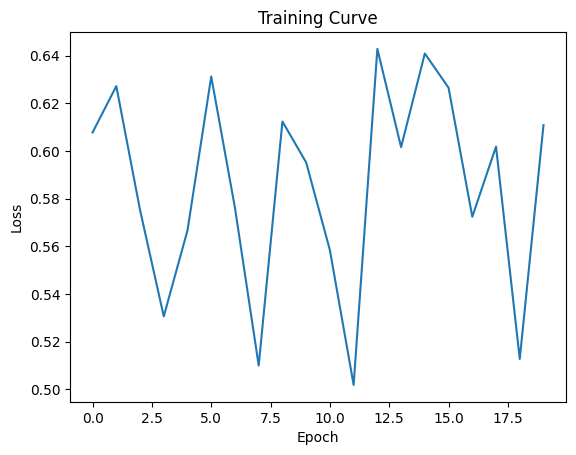

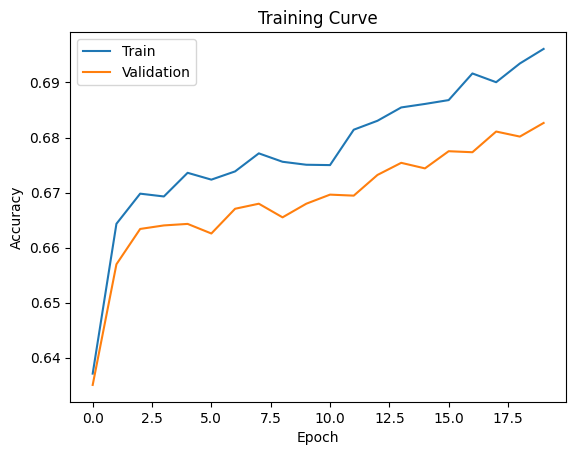

0.6864740944520862

In [125]:
model = TweetRNN(50, 50, 2)
train_loader = TweetBatcher(train, batch_size=64, drop_last=True)
valid_loader = TweetBatcher(valid, batch_size=64, drop_last=False)
train_rnn_network(model, train_loader, valid_loader, num_epochs=20, learning_rate=2e-4)
get_accuracy(model, test_loader)

The hidden size and the input embedding size don't have to be the same.

Epoch 1; Loss 0.680386; Train Acc 0.662042; Val Acc 0.655055
Epoch 2; Loss 0.646646; Train Acc 0.656123; Val Acc 0.650472
Epoch 3; Loss 0.636229; Train Acc 0.669934; Val Acc 0.665322
Epoch 4; Loss 0.627989; Train Acc 0.671748; Val Acc 0.665047
Epoch 5; Loss 0.593909; Train Acc 0.668597; Val Acc 0.662664
Epoch 6; Loss 0.599506; Train Acc 0.676203; Val Acc 0.667064
Epoch 7; Loss 0.564311; Train Acc 0.672289; Val Acc 0.666789
Epoch 8; Loss 0.635843; Train Acc 0.670952; Val Acc 0.663947
Epoch 9; Loss 0.617842; Train Acc 0.677762; Val Acc 0.672931
Epoch 10; Loss 0.607264; Train Acc 0.679544; Val Acc 0.661931
Epoch 11; Loss 0.621177; Train Acc 0.680817; Val Acc 0.672564
Epoch 12; Loss 0.560388; Train Acc 0.679767; Val Acc 0.667156
Epoch 13; Loss 0.666888; Train Acc 0.683649; Val Acc 0.667614
Epoch 14; Loss 0.529288; Train Acc 0.685018; Val Acc 0.675681
Epoch 15; Loss 0.616014; Train Acc 0.687532; Val Acc 0.673847
Epoch 16; Loss 0.598834; Train Acc 0.690523; Val Acc 0.675314
Epoch 17; Loss 0.

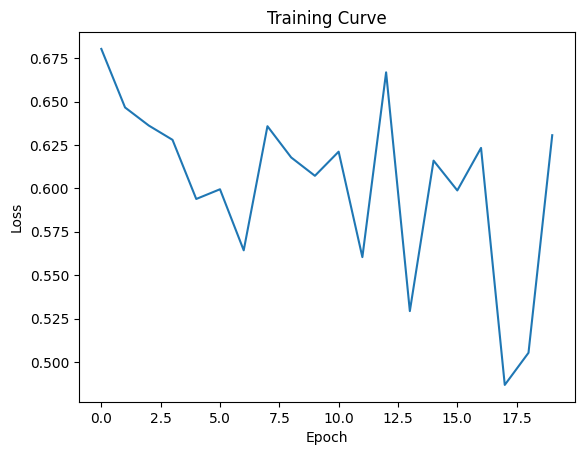

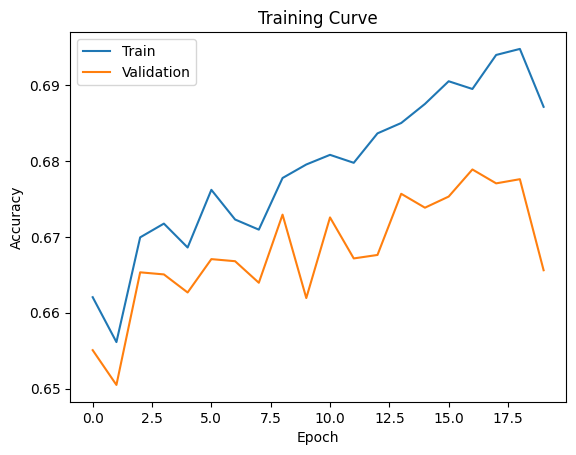

0.6768454837230629

In [126]:
model = TweetRNN(50, 100, 2)
train_rnn_network(model, train_loader, valid_loader, num_epochs=20, learning_rate=2e-4)
get_accuracy(model, test_loader)

##### Sentiment Analysis on New Tweets

In [127]:
def get_new_tweet(glove_vector, sample_tweet):
    tweet = sample_tweet
    idxs = [glove_vector.stoi[w]        # lookup the index of word
            for w in split_tweet(tweet)
            if w in glove_vector.stoi] # keep words that has an embedding
    idxs = torch.tensor(idxs) # convert list to pytorch tensor
    return idxs

In [128]:
new_tweet = get_new_tweet(glove, "This is a terrible tragedy")
print(new_tweet.shape)

out = torch.sigmoid(model(new_tweet.unsqueeze(0)))
pred = out.max(1, keepdim=True)[1]
print(pred)

torch.Size([5])
tensor([[0]])


In [129]:
new_tweet = get_new_tweet(glove, "This is the best day of my life")
print(new_tweet.shape)

out = torch.sigmoid(model(new_tweet.unsqueeze(0)))
pred = out.max(1, keepdim=True)[1]
print(pred)

torch.Size([8])
tensor([[1]])


Sentiment analysis is not a straight forward problem and it's impressive that without too much tunning we are able to get validation accuracy close to 70%. There are many ways that we can improve our performance:

*   Tune hyperparameters
*   Use all of the available data
*   Apply more advanced RNN architectures (ex. LSTM and GRU)

Epoch 1; Loss 0.692394; Train Acc 0.514607; Val Acc 0.512604
Epoch 2; Loss 0.687405; Train Acc 0.548530; Val Acc 0.541021
Epoch 3; Loss 0.695295; Train Acc 0.578984; Val Acc 0.576038
Epoch 4; Loss 0.673295; Train Acc 0.600210; Val Acc 0.596755
Epoch 5; Loss 0.649270; Train Acc 0.620545; Val Acc 0.619213
Epoch 6; Loss 0.635739; Train Acc 0.637570; Val Acc 0.639014
Epoch 7; Loss 0.618118; Train Acc 0.645367; Val Acc 0.645430
Epoch 8; Loss 0.674639; Train Acc 0.651222; Val Acc 0.648914
Epoch 9; Loss 0.603895; Train Acc 0.655041; Val Acc 0.649739
Epoch 10; Loss 0.608344; Train Acc 0.657968; Val Acc 0.651480
Epoch 11; Loss 0.673945; Train Acc 0.660610; Val Acc 0.654689
Epoch 12; Loss 0.667949; Train Acc 0.661883; Val Acc 0.655789
Epoch 13; Loss 0.658863; Train Acc 0.664779; Val Acc 0.657989
Epoch 14; Loss 0.630547; Train Acc 0.665383; Val Acc 0.659364
Epoch 15; Loss 0.573861; Train Acc 0.667197; Val Acc 0.658172
Epoch 16; Loss 0.623095; Train Acc 0.668406; Val Acc 0.660372
Epoch 17; Loss 0.

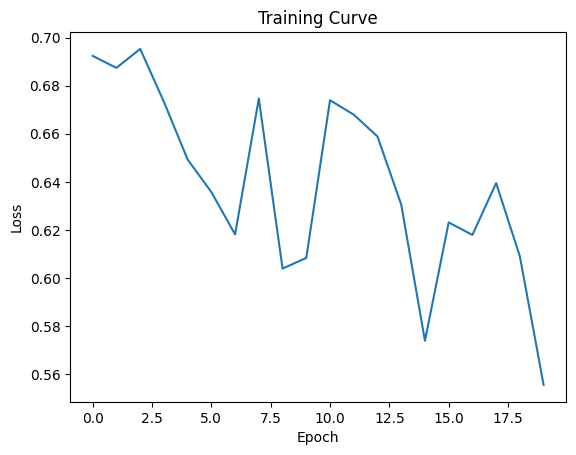

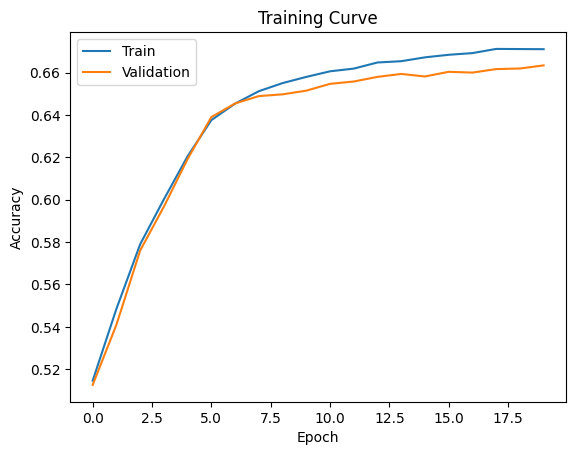

0.6653828519027969

In [130]:
class TweetLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(TweetLSTM, self).__init__()
        self.emb = nn.Embedding.from_pretrained(glove.vectors)
        self.hidden_size = hidden_size
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Look up the embedding
        x = self.emb(x)
        # Set an initial hidden state and cell state
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        c0 = torch.zeros(1, x.size(0), self.hidden_size)
        # Forward propagate the LSTM
        out, _ = self.rnn(x, (h0, c0))
        # Pass the output of the last time step to the classifier
        out = self.fc(out[:, -1, :])
        return out

model = TweetLSTM(50, 50, 2)
train_rnn_network(model, train_loader, valid_loader, num_epochs=20, learning_rate=2e-5)
get_accuracy(model, test_loader)

# Results

## Summary

This notebook explored modern NLP techniques for text representation and sequence modeling using PyTorch.

### Implemented Components

- Word2Vec embeddings
- GloVe embeddings
- Semantic similarity
- Word analogy reasoning
- Bias analysis
- Sentiment analysis
- Recurrent Neural Networks (RNNs)
- Variable-length sequence batching

### Key Outcomes

- Demonstrated how word embeddings capture semantic relationships.
- Measured semantic similarity using cosine similarity.
- Solved analogy tasks using vector arithmetic.
- Investigated bias present in pretrained embeddings.
- Built an end-to-end tweet sentiment classifier using recurrent neural networks.
- Explored batching strategies for variable-length text sequences.

# Conclusion

This notebook introduced the core components of modern Natural Language Processing using PyTorch. Beginning with distributed word representations, it demonstrated how pretrained embeddings encode semantic information that can be leveraged for downstream tasks. The notebook concluded by implementing a recurrent neural network for tweet sentiment classification, illustrating how sequential neural networks can effectively model natural language data.